Block 1 — Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# LOCAL LOAD - baca CSV dari folder project
data_path = Path(r'E:\Work-Project\machine-learning-tr\ai4i2020.csv')
if not data_path.exists():
    data_path = Path('ai4i2020.csv')
if not data_path.exists():
    raise FileNotFoundError('ai4i2020.csv tidak ditemukan di folder project')

df = pd.read_csv(data_path)
print(f'File: {data_path.resolve()}')
print(df.shape)
df.head()

def detect_xgb_gpu():
    try:
        X = np.random.randn(64, 4)
        y = (X[:, 0] > 0).astype(int)
        XGBClassifier(n_estimators=1, device='cuda', tree_method='hist').fit(X, y)
        return {'device': 'cuda', 'tree_method': 'hist'}
    except Exception as e:
        print(f'XGBoost GPU tidak tersedia, pakai CPU. ({type(e).__name__})')
        return {'device': 'cpu', 'tree_method': 'hist'}

def detect_catboost_gpu():
    try:
        from catboost import CatBoostClassifier
        X = np.random.randn(64, 4)
        y = (X[:, 0] > 0).astype(int)
        CatBoostClassifier(iterations=1, task_type='GPU', verbose=0).fit(X, y)
        return {'task_type': 'GPU'}
    except Exception as e:
        print(f'CatBoost GPU tidak tersedia, pakai CPU. ({type(e).__name__})')
        return {'task_type': 'CPU'}

XGB_DEVICE = detect_xgb_gpu()
CB_DEVICE = detect_catboost_gpu()
GPU_N_JOBS = 1 if XGB_DEVICE.get('device') == 'cuda' else -1

print(f'XGBoost device: {XGB_DEVICE}')
print(f'CatBoost device: {CB_DEVICE}')
print(f'Search n_jobs (GPU-safe): {GPU_N_JOBS}')


File: E:\Work-Project\machine-learning-tr\ai4i2020.csv
(10000, 14)
XGBoost device: {'device': 'cuda', 'tree_method': 'hist'}
CatBoost device: {'task_type': 'GPU'}
Search n_jobs (GPU-safe): 1


Block 2 — EDA: Distribusi Target & Failure Modes

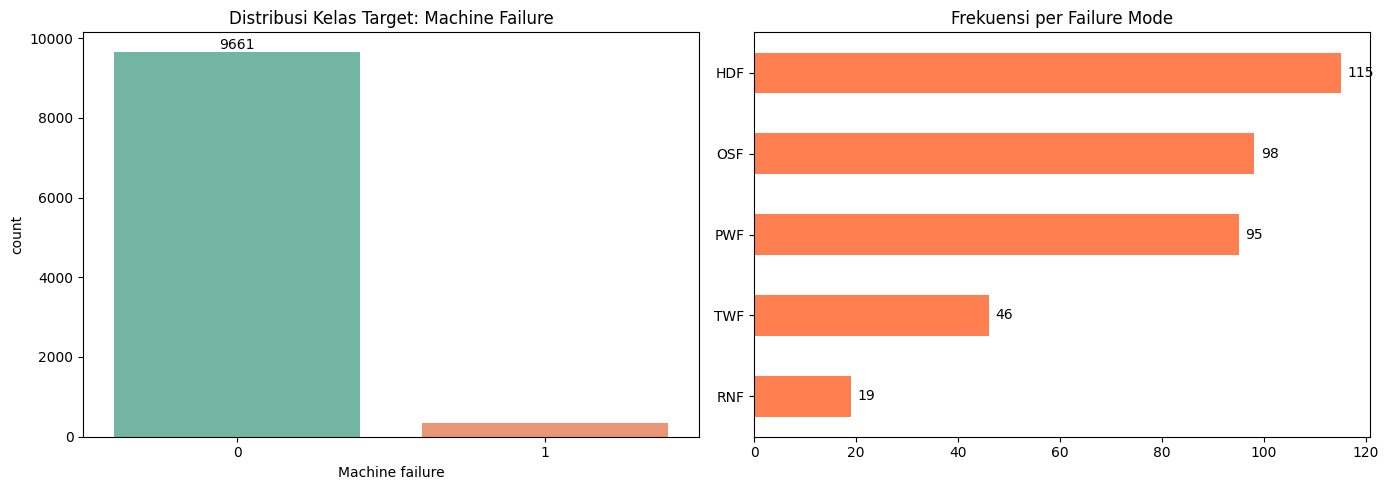

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Machine failure distribution
sns.countplot(x='Machine failure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Kelas Target: Machine Failure')
axes[0].bar_label(axes[0].containers[0])

# Plot 2: Failure mode frequencies
failure_modes = df[['TWF','HDF','PWF','OSF','RNF']].sum()
failure_modes.sort_values().plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Frekuensi per Failure Mode')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=5)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150)
plt.show()

Block 3 — EDA: Distribusi Fitur Sensor (Histogram + KDE)

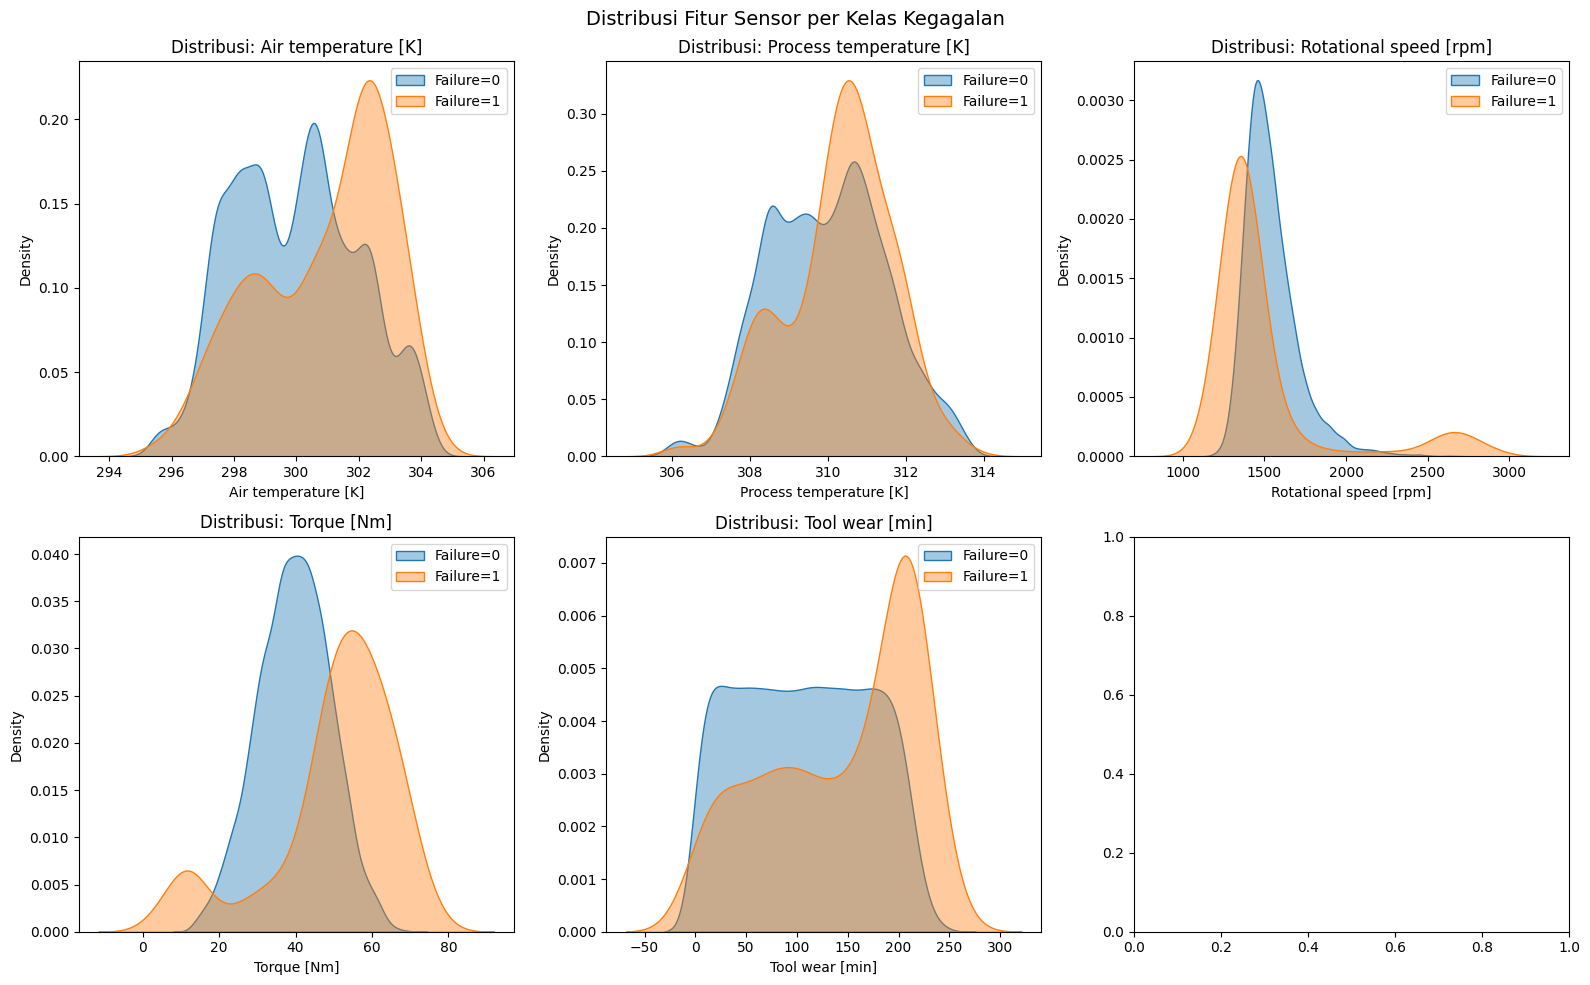

In [3]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, grp in df.groupby('Machine failure'):
        sns.kdeplot(grp[col], ax=axes[i], label=f'Failure={label}', fill=True, alpha=0.4)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].legend()
plt.suptitle('Distribusi Fitur Sensor per Kelas Kegagalan', fontsize=14)
plt.tight_layout()
plt.savefig('fig2_sensor_distribution.png', dpi=150)
plt.show()

Block 4 — EDA: Boxplot Sensor vs Machine Failure

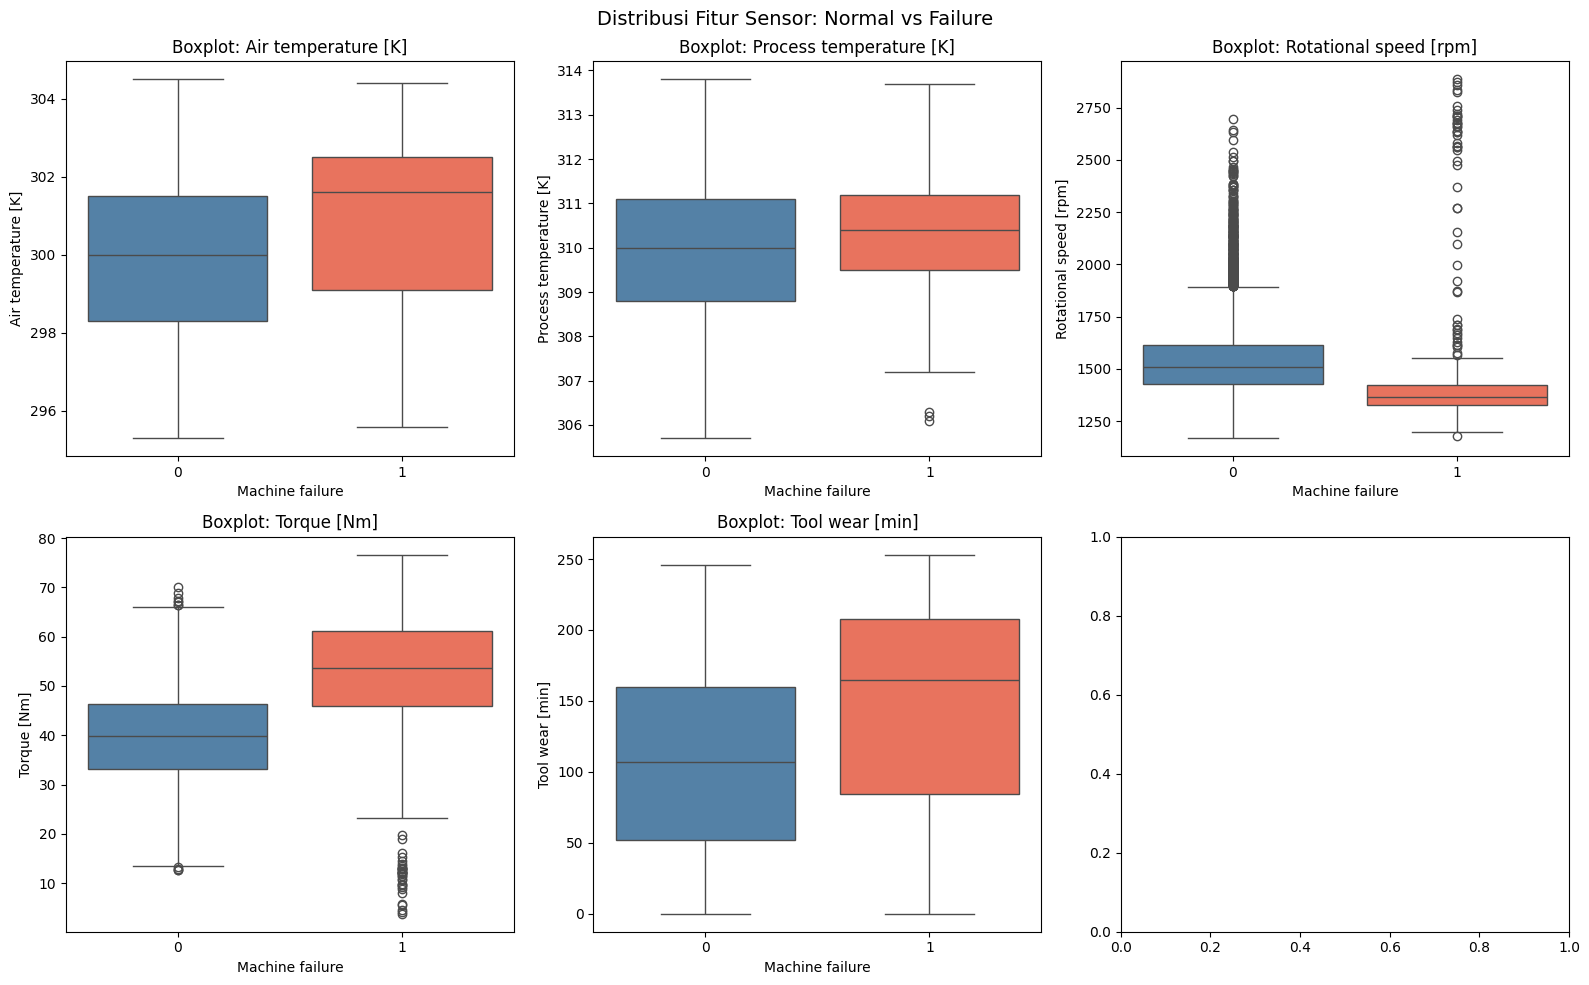

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Machine failure', y=col, data=df,
                palette={'0':'steelblue', '1':'tomato'}, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Distribusi Fitur Sensor: Normal vs Failure', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_boxplot_sensor.png', dpi=150)
plt.show()

Block 5 — EDA: Heatmap Korelasi

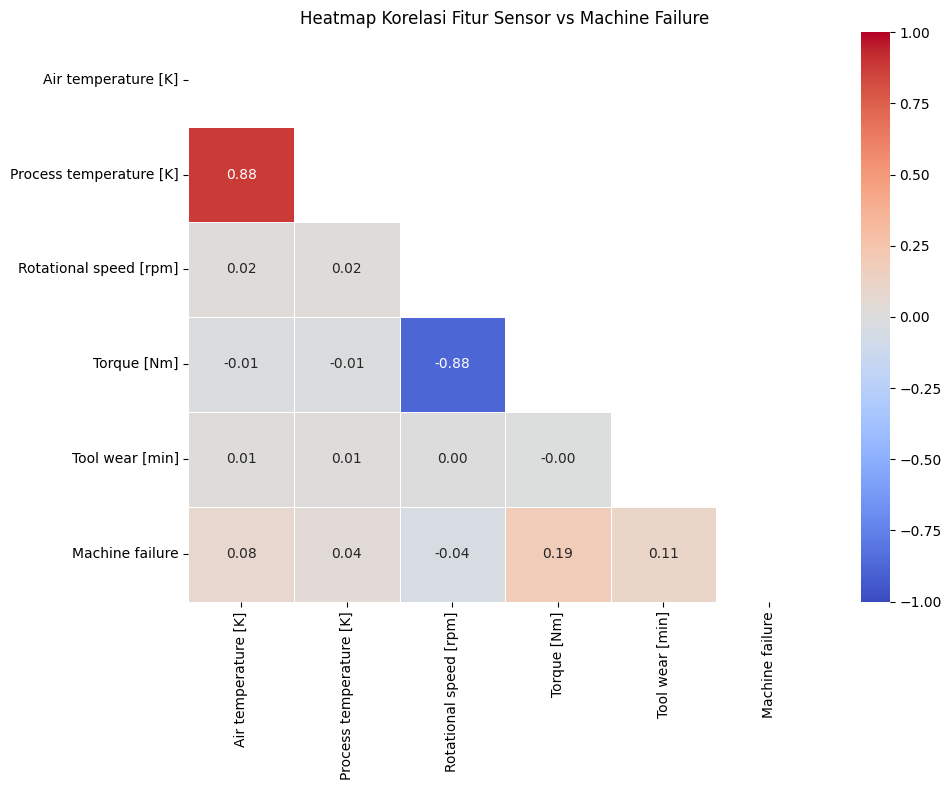

In [5]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['Machine failure']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Sensor vs Machine Failure')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150)
plt.show()

Block 6 — EDA: Scatter Plot Zona Kegagalan

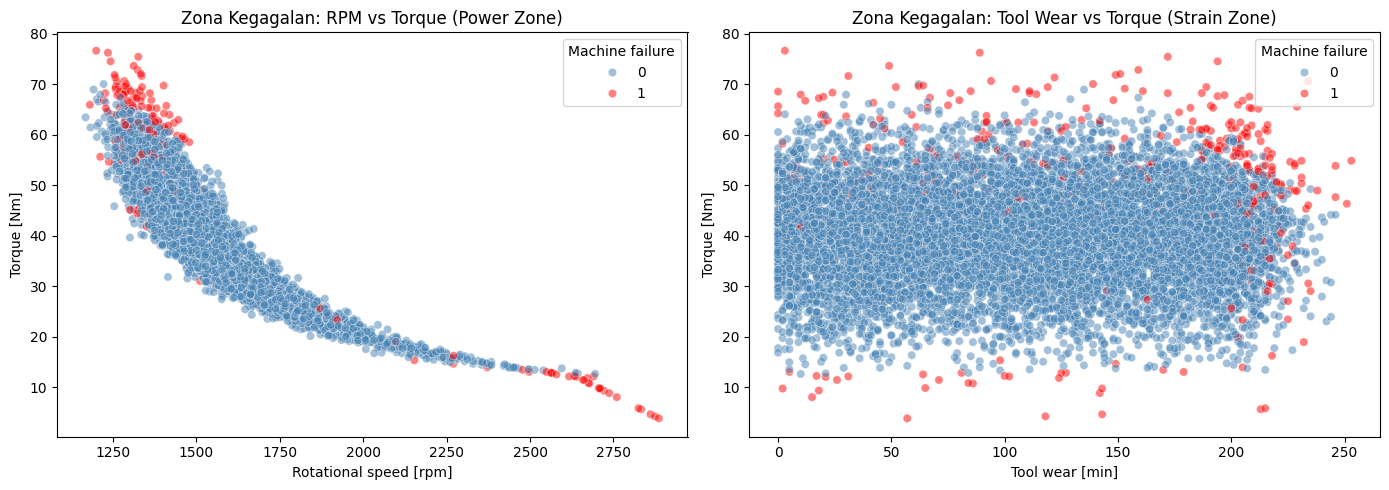

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: RPM vs Torque
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]',
                hue='Machine failure', palette={0:'steelblue', 1:'red'},
                alpha=0.5, data=df, ax=axes[0])
axes[0].set_title('Zona Kegagalan: RPM vs Torque (Power Zone)')

# Scatter 2: Tool Wear vs Torque
sns.scatterplot(x='Tool wear [min]', y='Torque [Nm]',
                hue='Machine failure', palette={0:'steelblue', 1:'red'},
                alpha=0.5, data=df, ax=axes[1])
axes[1].set_title('Zona Kegagalan: Tool Wear vs Torque (Strain Zone)')
plt.tight_layout()
plt.savefig('fig5_scatter_failure_zones.png', dpi=150)
plt.show()

Block 7 — Preprocessing: Feature Engineering + Encoding

In [7]:
# Feature engineering
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']     = df['Rotational speed [rpm]'] * df['Torque [Nm]']
df['Strain']    = df['Torque [Nm]'] * df['Tool wear [min]']

# Encoding tipe produk
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Hapus kolom tidak informatif
df.drop(['UDI', 'Product ID'], axis=1, inplace=True, errors='ignore')

print("Shape setelah preprocessing:", df.shape)
print(df.dtypes)

Shape setelah preprocessing: (10000, 15)
Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Temp_diff                  float64
Power                      float64
Strain                     float64
dtype: object


Block 8 — Preprocessing: Deteksi & Winsorization Outlier

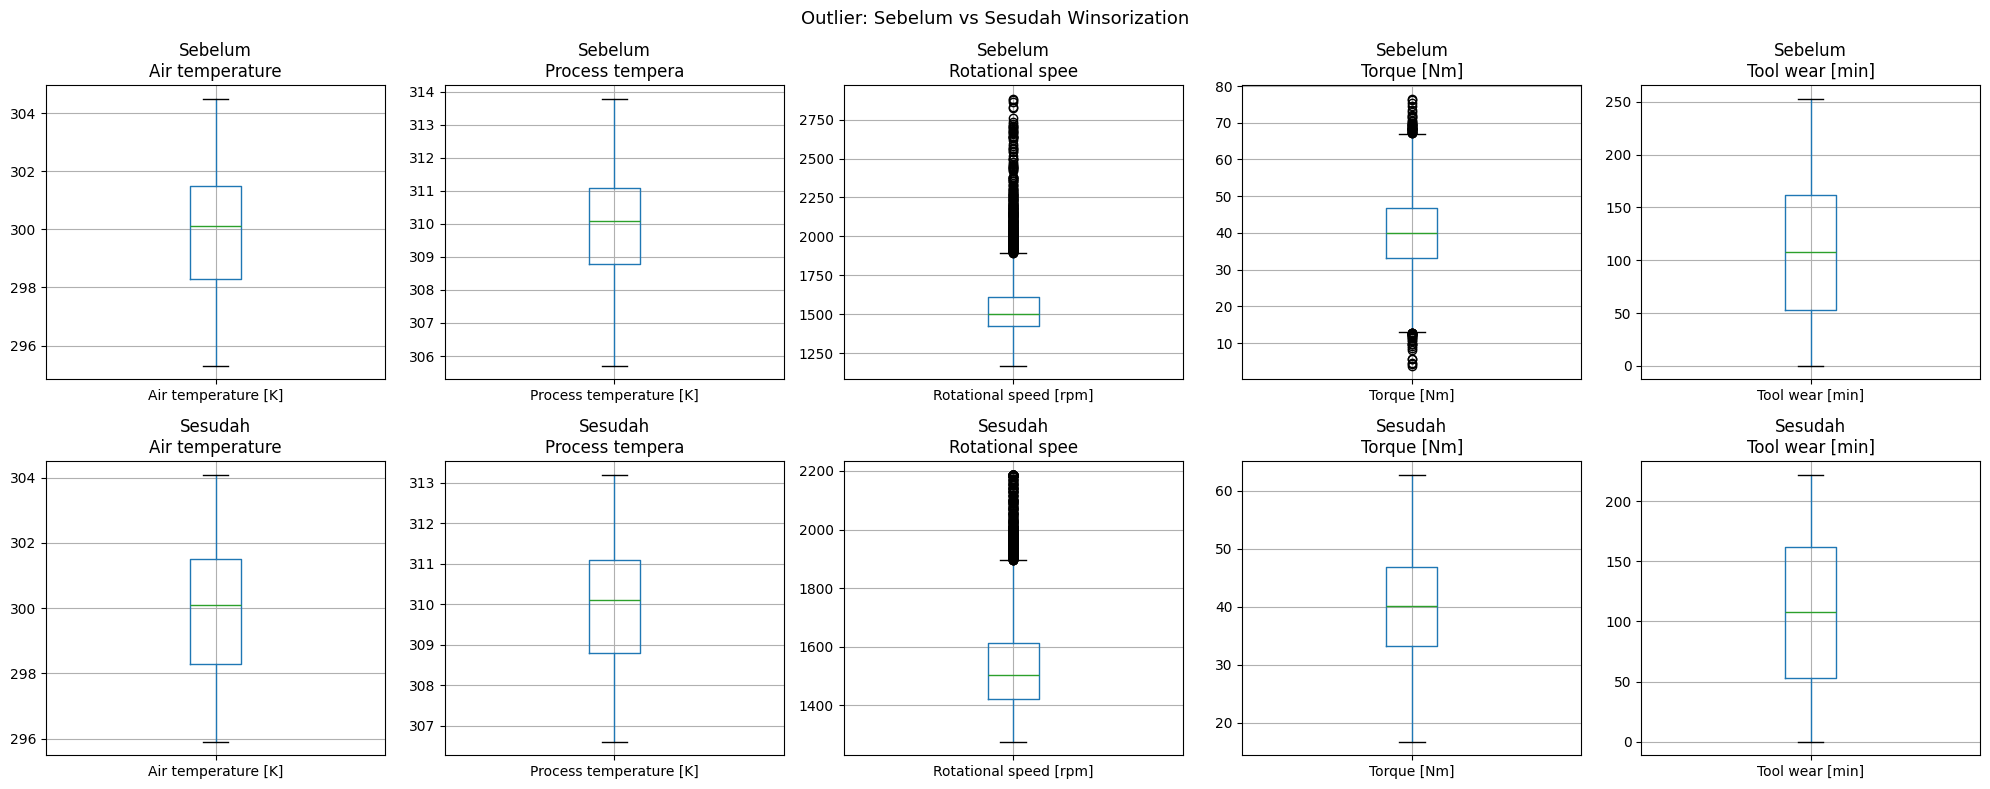

In [8]:
from scipy.stats.mstats import winsorize

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
all_num = ['Air temperature [K]', 'Process temperature [K]',
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for i, col in enumerate(all_num):
    # Sebelum
    df[[col]].boxplot(ax=axes[0, i])
    axes[0, i].set_title(f'Sebelum\n{col[:15]}')
    # Winsorize
    df[col] = winsorize(df[col], limits=[0.01, 0.01])
    # Sesudah
    df[[col]].boxplot(ax=axes[1, i])
    axes[1, i].set_title(f'Sesudah\n{col[:15]}')

plt.suptitle('Outlier: Sebelum vs Sesudah Winsorization', fontsize=13)
plt.tight_layout()
plt.savefig('fig6_outlier_treatment.png', dpi=150)
plt.show()

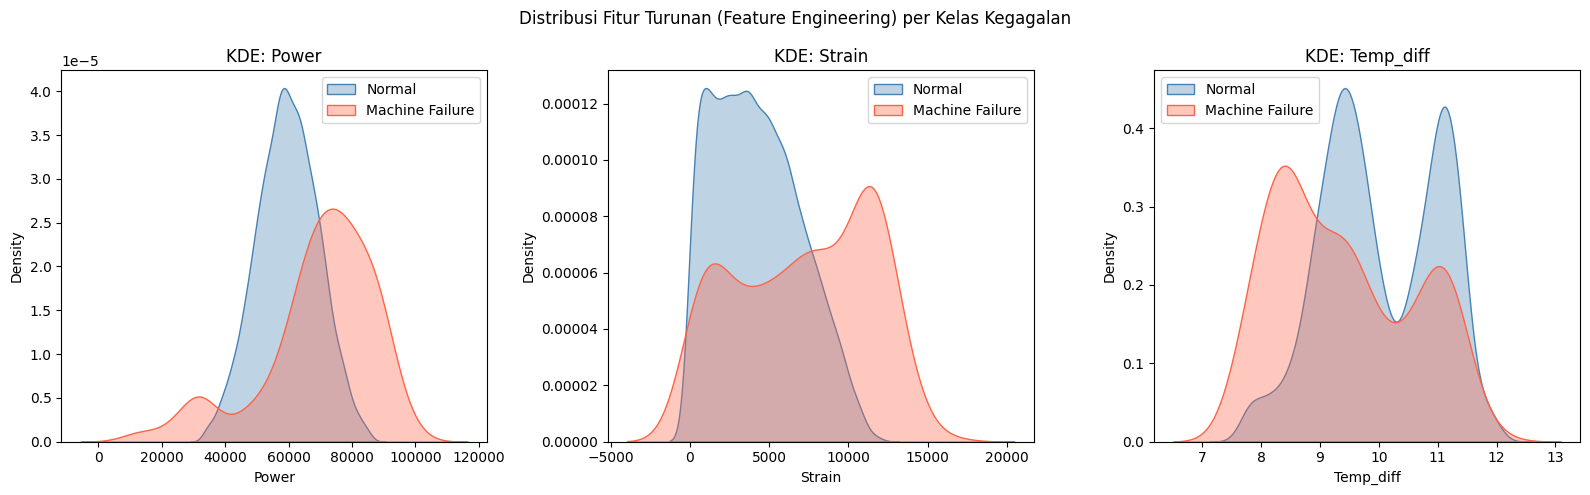

In [9]:
# KDE Fitur Turunan (Feature Engineering)
derived_cols = ['Power', 'Strain', 'Temp_diff']
labels = {0: 'Normal', 1: 'Machine Failure'}
colors = {0: 'steelblue', 1: 'tomato'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(derived_cols):
    for label in [0, 1]:
        subset = df[df['Machine failure'] == label][col]
        sns.kdeplot(subset, ax=axes[i], label=labels[label],
                    color=colors[label], fill=True, alpha=0.35)
    axes[i].set_title(f'KDE: {col}')
    axes[i].legend()
plt.suptitle('Distribusi Fitur Turunan (Feature Engineering) per Kelas Kegagalan')
plt.tight_layout()
plt.savefig('fig8_kde_derived_features.png', dpi=150)
plt.show()


Block 9 — Preprocessing: Splitting + SMOTE (strategy=0.2 anti-overfit)


Train: (7000, 9), Val: (1000, 9), Test: (2000, 9)
Distribusi kelas Train sebelum SMOTE:
Machine failure
0    6763
1     237
Name: count, dtype: int64

Distribusi kelas Train sesudah SMOTE (0.2):
Machine failure
0    6763
1    1352
Name: count, dtype: int64


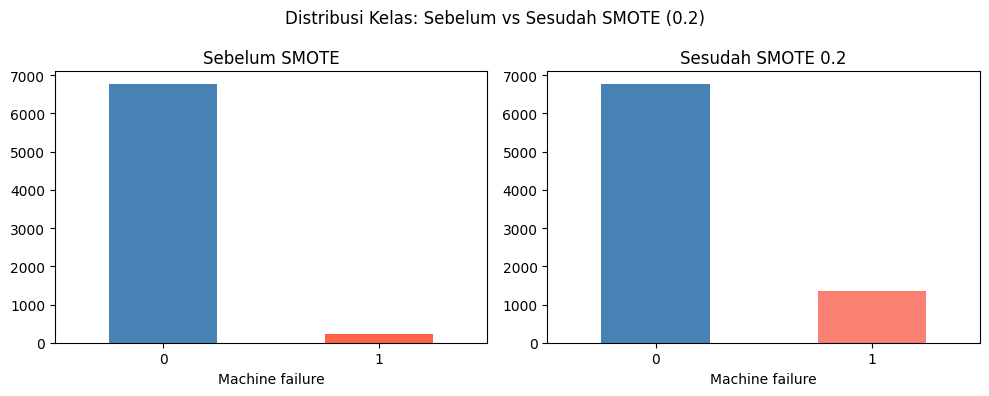

In [10]:
X = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Distribusi kelas Train sebelum SMOTE:\n{y_train.value_counts()}')

# SMOTE 0.2 (turun dari 0.3) agar tree models tidak overfit ke sampel sintetis sengaja diturunkan by mamat
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.2)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f'\nDistribusi kelas Train sesudah SMOTE (0.2):\n{pd.Series(y_res).value_counts()}')

def clean_cols(frame):
    frame = frame.copy()
    frame.columns = [
        col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_')
        for col in frame.columns
    ]
    return frame

X_train = clean_cols(X_train)
X_val = clean_cols(X_val)
X_test = clean_cols(X_test)
X_res = clean_cols(X_res)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                             title='Sebelum SMOTE', rot=0)
pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'],
                                      title='Sesudah SMOTE 0.2', rot=0)
plt.suptitle('Distribusi Kelas: Sebelum vs Sesudah SMOTE (0.2)')
plt.tight_layout()
plt.savefig('fig7_smote_comparison.png', dpi=150)
plt.show()


Block 10 — Inisialisasi Model (anti-overfit defaults)


In [11]:
from sklearn.pipeline import Pipeline

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ratio_raw = y_train.value_counts()[0] / y_train.value_counts()[1]
# Data sudah SMOTE 0.2 → JANGAN double-balance
ratio = 1.0

xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    subsample=1.0, colsample_bytree=1.0, min_child_weight=1,
    scale_pos_weight=1.0, eval_metric='logloss', random_state=42, **XGB_DEVICE)

# RF tanpa class_weight: SMOTE sudah menyeimbangkan sebagian
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=2, min_samples_split=5,
    class_weight=None, random_state=42, n_jobs=-1)

lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

print('Model awal (GB-matched, no double-balance)')
print(f'  XGB scale_pos_weight={ratio:.1f} | raw imbalance={ratio_raw:.2f}')
print(f'  RF class_weight=None (SMOTE saja, seperti GB)')
print(f'  XGBoost device: {XGB_DEVICE}')


Model awal (GB-matched, no double-balance)
  XGB scale_pos_weight=1.0 | raw imbalance=28.54
  RF class_weight=None (SMOTE saja, seperti GB)
  XGBoost device: {'device': 'cuda', 'tree_method': 'hist'}


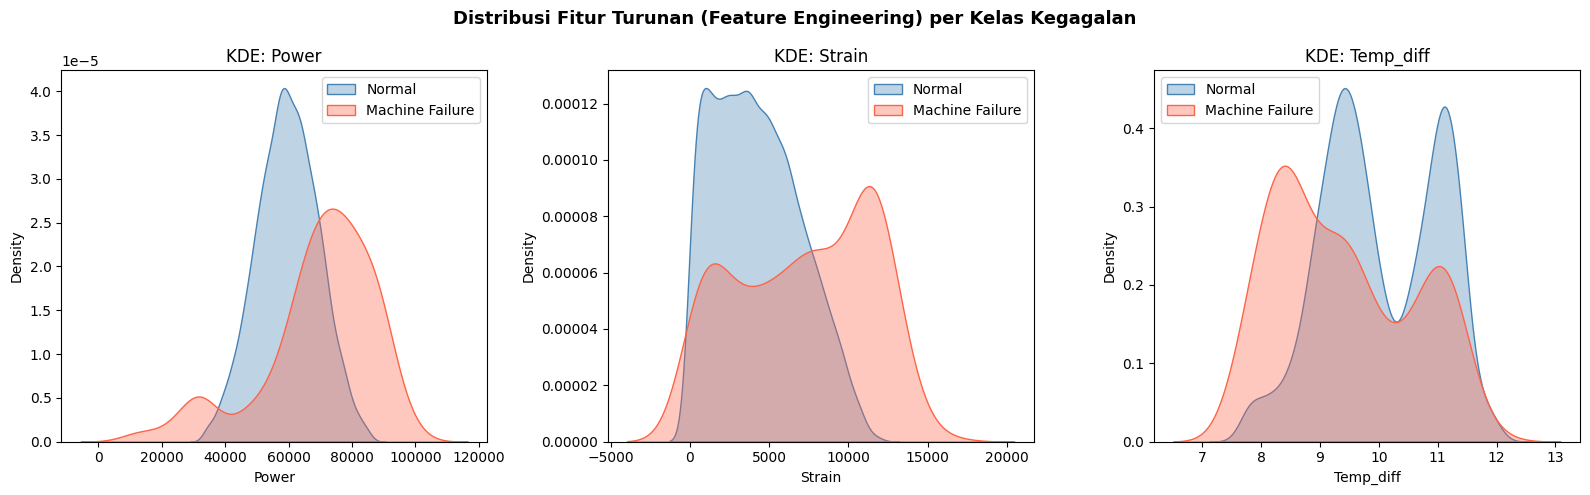

In [12]:
derived_cols = ['Power', 'Strain', 'Temp_diff']
labels = {0: 'Normal', 1: 'Machine Failure'}
colors = {0: 'steelblue', 1: 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(derived_cols):
    for label in [0, 1]:
        subset = df[df['Machine failure'] == label][col]
        sns.kdeplot(subset, ax=axes[i],
                    label=labels[label],
                    color=colors[label],
                    fill=True, alpha=0.35)
    axes[i].set_title(f'KDE: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Distribusi Fitur Turunan (Feature Engineering) per Kelas Kegagalan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_kde_derived_features.png', dpi=150)
plt.show()

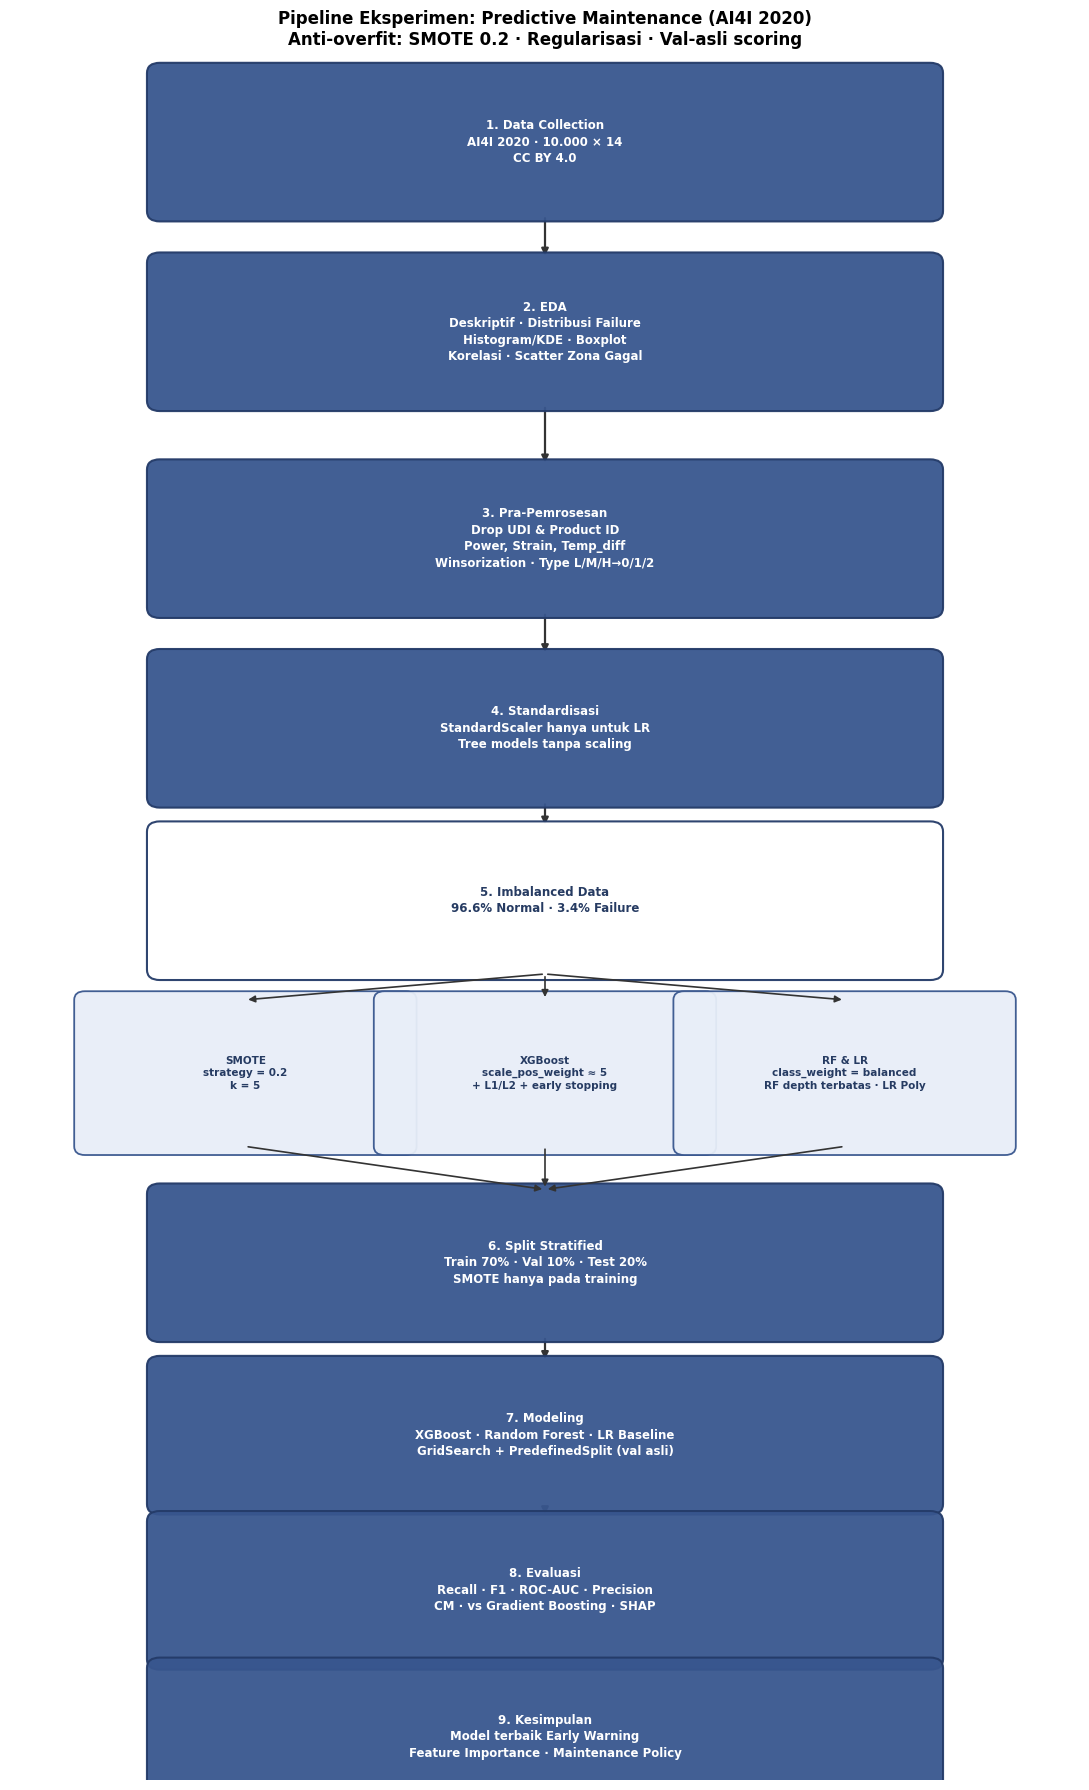

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 18))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

main = [
    (5, 19.0, '1. Data Collection\nAI4I 2020 · 10.000 × 14\nCC BY 4.0'),
    (5, 16.8, '2. EDA\nDeskriptif · Distribusi Failure\nHistogram/KDE · Boxplot\nKorelasi · Scatter Zona Gagal'),
    (5, 14.4, '3. Pra-Pemrosesan\nDrop UDI & Product ID\nPower, Strain, Temp_diff\nWinsorization · Type L/M/H→0/1/2'),
    (5, 12.2, '4. Standardisasi\nStandardScaler hanya untuk LR\nTree models tanpa scaling'),
    (5, 10.2, '5. Imbalanced Data\n96.6% Normal · 3.4% Failure'),
    (5, 6.0, '6. Split Stratified\nTrain 70% · Val 10% · Test 20%\nSMOTE hanya pada training'),
    (5, 4.0, '7. Modeling\nXGBoost · Random Forest · LR Baseline\nGridSearch + PredefinedSplit (val asli)'),
    (5, 2.2, '8. Evaluasi\nRecall · F1 · ROC-AUC · Precision\nCM · vs Gradient Boosting · SHAP'),
    (5, 0.5, '9. Kesimpulan\nModel terbaik Early Warning\nFeature Importance · Maintenance Policy'),
]
branches = [
    (2.2, 8.2, 'SMOTE\nstrategy = 0.2\nk = 5'),
    (5.0, 8.2, 'XGBoost\nscale_pos_weight ≈ 5\n+ L1/L2 + early stopping'),
    (7.8, 8.2, 'RF & LR\nclass_weight = balanced\nRF depth terbatas · LR Poly'),
]

box_w, box_h = 7.2, 1.6
for x, y, label in main:
    color = '#ffffff' if y == 10.2 else '#38568e'
    tc = '#263b62' if y == 10.2 else 'white'
    ax.add_patch(FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                                boxstyle='round,pad=0.12', linewidth=1.5,
                                edgecolor='#243b68', facecolor=color, alpha=0.95, zorder=2))
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, color=tc,
            fontweight='bold', zorder=3, linespacing=1.35)

for x, y, label in branches:
    ax.add_patch(FancyBboxPatch((x - 1.5, y - 0.85), 3.0, 1.7, boxstyle='round,pad=0.1',
                                linewidth=1.3, edgecolor='#38568e', facecolor='#e8eef8',
                                alpha=0.95, zorder=2))
    ax.text(x, y, label, ha='center', va='center', fontsize=7.5, color='#263b62',
            fontweight='bold', zorder=3, linespacing=1.3)

spine = [19.0, 16.8, 14.4, 12.2, 10.2, 6.0, 4.0, 2.2, 0.5]
for i in range(len(spine) - 1):
    if spine[i] == 10.2:
        continue
    ax.annotate('', xy=(5, spine[i + 1] + 0.85), xytext=(5, spine[i] - 0.85),
                arrowprops=dict(arrowstyle='-|>', color='#333333', lw=1.6), zorder=1)
for x in (2.2, 5.0, 7.8):
    ax.annotate('', xy=(x, 9.05), xytext=(5, 9.35),
                arrowprops=dict(arrowstyle='-|>', color='#333333', lw=1.2))
    ax.annotate('', xy=(5, 6.85), xytext=(x, 7.35),
                arrowprops=dict(arrowstyle='-|>', color='#333333', lw=1.2))

plt.title('Pipeline Eksperimen: Predictive Maintenance (AI4I 2020)\nAnti-overfit: SMOTE 0.2 · Regularisasi · Val-asli scoring',
          fontsize=12, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('fig10_pipeline_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Block 11 — Tuning agar menyamai GB
# Kunci: train di SMOTE tanpa extra class_weight; skor di validation ASLI
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_recall_curve

X_combined = np.vstack([X_res, X_val])
y_combined = np.concatenate([y_res, y_val])
ps = PredefinedSplit(np.concatenate([np.full(len(X_res), -1), np.full(len(X_val), 0)]))

# --- XGBoost mirip sklearn GB (depth=3, lr=0.1) + sedikit grid ---
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'reg_lambda': [1, 3],
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=1.0, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    param_grid=xgb_params, scoring='f1', cv=ps, n_jobs=GPU_N_JOBS, verbose=1)
xgb_grid.fit(X_combined, y_combined)
print('Best XGBoost params:', xgb_grid.best_params_)
print('Best Val-asli F1:', xgb_grid.best_score_)

xgb_best = XGBClassifier(
    **xgb_grid.best_params_, scale_pos_weight=1.0, eval_metric='logloss',
    random_state=42, early_stopping_rounds=20, **XGB_DEVICE)
xgb_best.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=False)

# --- RF tanpa class_weight (hindari double-balance) ---
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [None, 16],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': [None],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params, scoring='f1', cv=ps, n_jobs=-1, verbose=1)
rf_grid.fit(X_combined, y_combined)
print('Best Random Forest params:', rf_grid.best_params_)
print('Best Val-asli F1:', rf_grid.best_score_)

# Refit pemenang grid di X_res saja (best_estimator_ GridSearchCV default-nya refit ke train+val)
rf_grid_refit = RandomForestClassifier(
    **{k: v for k, v in rf_grid.best_params_.items()},
    random_state=42, n_jobs=-1)
rf_grid_refit.fit(X_res, y_res)

# --- RF++ : subsample bagging + soft-vote RF-dominated (pilih via VAL, bukan test) ---
# max_samples=0.7 mengurangi korelasi antar pohon (precision naik, FP turun)
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, GradientBoostingClassifier

rf_tree = RandomForestClassifier(
    n_estimators=800, max_depth=None, min_samples_split=2, min_samples_leaf=1,
    max_features='sqrt', max_samples=0.7, class_weight=None,
    random_state=42, n_jobs=-1)
rf_tree.fit(X_res, y_res)

rf_vote = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=800, max_depth=None, min_samples_split=2, min_samples_leaf=1,
            max_features='sqrt', max_samples=0.7, class_weight=None,
            random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('et', ExtraTreesClassifier(
            n_estimators=500, max_features='sqrt', max_samples=0.7,
            bootstrap=True, random_state=42, n_jobs=-1)),
    ],
    voting='soft', weights=[2, 1, 1],
)
rf_vote.fit(X_res, y_res)

_rf_cands = {
    'RF grid': rf_grid_refit,
    'RF subsample (max_samples=0.7)': rf_tree,
    'RF vote (RF+GB+ET, bobot 2-1-1)': rf_vote,
}
print('\n=== Pilih RF final dari VALIDATION F1 ===')
_rf_scores = {}
for _n, _m in _rf_cands.items():
    _f = f1_score(y_val, _m.predict(X_val))
    _rf_scores[_n] = _f
    print(f'  {_n}: Val F1={_f:.4f}')
_rf_winner = max(_rf_scores, key=_rf_scores.get)
rf_best = _rf_cands[_rf_winner]
print(f'→ RF final: {_rf_winner}')

# --- LR Polynomial di data asli + class_weight (bukan SMOTE) ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=3000, random_state=42)),
])
lr_params = {'clf__C': [0.1, 1, 10], 'clf__penalty': ['l1', 'l2']}
ps_lr = PredefinedSplit(np.concatenate([np.full(len(X_train), -1), np.full(len(X_val), 0)]))
lr_grid = GridSearchCV(lr_pipe, param_grid=lr_params, scoring='f1', cv=ps_lr, n_jobs=-1, verbose=1)
lr_grid.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
print('Best LR-Poly params:', lr_grid.best_params_)
print('Best Val-asli F1:', lr_grid.best_score_)
lr_best = lr_grid.best_estimator_

xgb_grid.best_estimator_ = xgb_best
rf_grid.best_estimator_ = rf_best
lr_grid.best_estimator_ = lr_best

def best_f1_threshold(model, X_v, y_v):
    proba = model.predict_proba(X_v)[:, 1]
    prec, rec, thr = precision_recall_curve(y_v, proba)
    f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    idx = int(np.nanargmax(f1s))
    return float(thr[idx]), float(f1s[idx])

print('\n=== Threshold optimal di VALIDATION (bukan test) ===')
best_thresholds = {}
for name, model, Xv, yv in [
    ('XGBoost (reg)', xgb_best, X_val, y_val),
    ('Random Forest (reg)', rf_best, X_val, y_val),
    ('LR-Poly (reg)', lr_best, X_val, y_val),
]:
    t, f = best_f1_threshold(model, Xv, yv)
    best_thresholds[name] = t
    print(f'{name}: thr={t:.3f} | Val F1={f:.4f}')

print('\nTuning selesai.')


Fitting 1 folds for each of 96 candidates, totalling 96 fits
Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
Best Val-asli F1: 0.90625
Fitting 1 folds for each of 16 candidates, totalling 16 fits
Best Random Forest params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Val-asli F1: 0.9230769230769231

=== Pilih RF final dari VALIDATION F1 ===
  RF grid: Val F1=0.9231
  RF subsample (max_samples=0.7): Val F1=0.8955
  RF vote (RF+GB+ET, bobot 2-1-1): Val F1=0.9375
→ RF final: RF vote (RF+GB+ET, bobot 2-1-1)
Fitting 1 folds for each of 6 candidates, totalling 6 fits
Best LR-Poly params: {'clf__C': 10, 'clf__penalty': 'l1'}
Best Val-asli F1: 0.4177215189873418

=== Threshold optimal di VALIDATION (bukan test) ===
XGBoost (reg): thr=0.846 | Val F1=0.9206
Random Forest (reg): thr=0.603 | Val F1=0.9375
LR-Poly (

=== Gap Train vs Val (target < 0.05) ===
XGBoost (reg) — Train F1: 0.9244 | Val F1: 0.9062 | Gap: 0.0182
Random Forest (reg) — Train F1: 0.9899 | Val F1: 0.9375 | Gap: 0.0524
LR-Poly — Train F1: 0.4198 | Val F1: 0.4314 | Gap: -0.0116


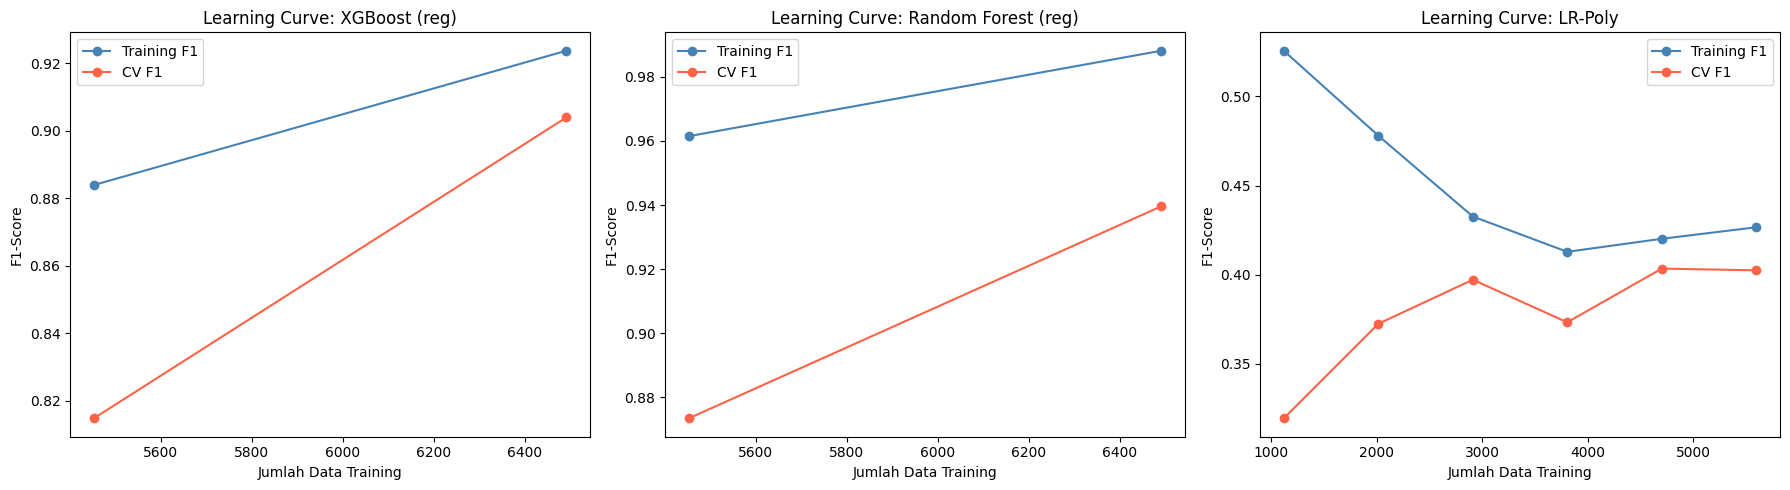

In [15]:
# Block 12 — Diagnosa gap Train vs Val setelah regularisasi
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score

def report_gap(name, model, X_tr, y_tr, X_v, y_v):
    tr = f1_score(y_tr, model.predict(X_tr))
    va = f1_score(y_v, model.predict(X_v))
    print(f'{name} — Train F1: {tr:.4f} | Val F1: {va:.4f} | Gap: {tr - va:.4f}')

print('=== Gap Train vs Val (target < 0.05) ===')
report_gap('XGBoost (reg)', xgb_best, X_res, y_res, X_val, y_val)
report_gap('Random Forest (reg)', rf_best, X_res, y_res, X_val, y_val)
report_gap('LR-Poly', lr_best, X_train, y_train, X_val, y_val)

def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='f1', train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1)
    tm, vm = train_scores.mean(axis=1), val_scores.mean(axis=1)
    ax.plot(train_sizes, tm, 'o-', color='steelblue', label='Training F1')
    ax.plot(train_sizes, vm, 'o-', color='tomato', label='CV F1')
    ax.set_title(title); ax.set_xlabel('Jumlah Data Training'); ax.set_ylabel('F1-Score'); ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
xgb_lc = XGBClassifier(**{k: v for k, v in xgb_grid.best_params_.items()},
                       scale_pos_weight=ratio, eval_metric='logloss', random_state=42, **XGB_DEVICE)
plot_learning_curve(xgb_lc, X_res, y_res, 'Learning Curve: XGBoost (reg)', axes[0])
plot_learning_curve(rf_best, X_res, y_res, 'Learning Curve: Random Forest (reg)', axes[1])
plot_learning_curve(lr_best, X_train, y_train, 'Learning Curve: LR-Poly', axes[2])
plt.tight_layout(); plt.savefig('fig11_learning_curves.png', dpi=150); plt.show()


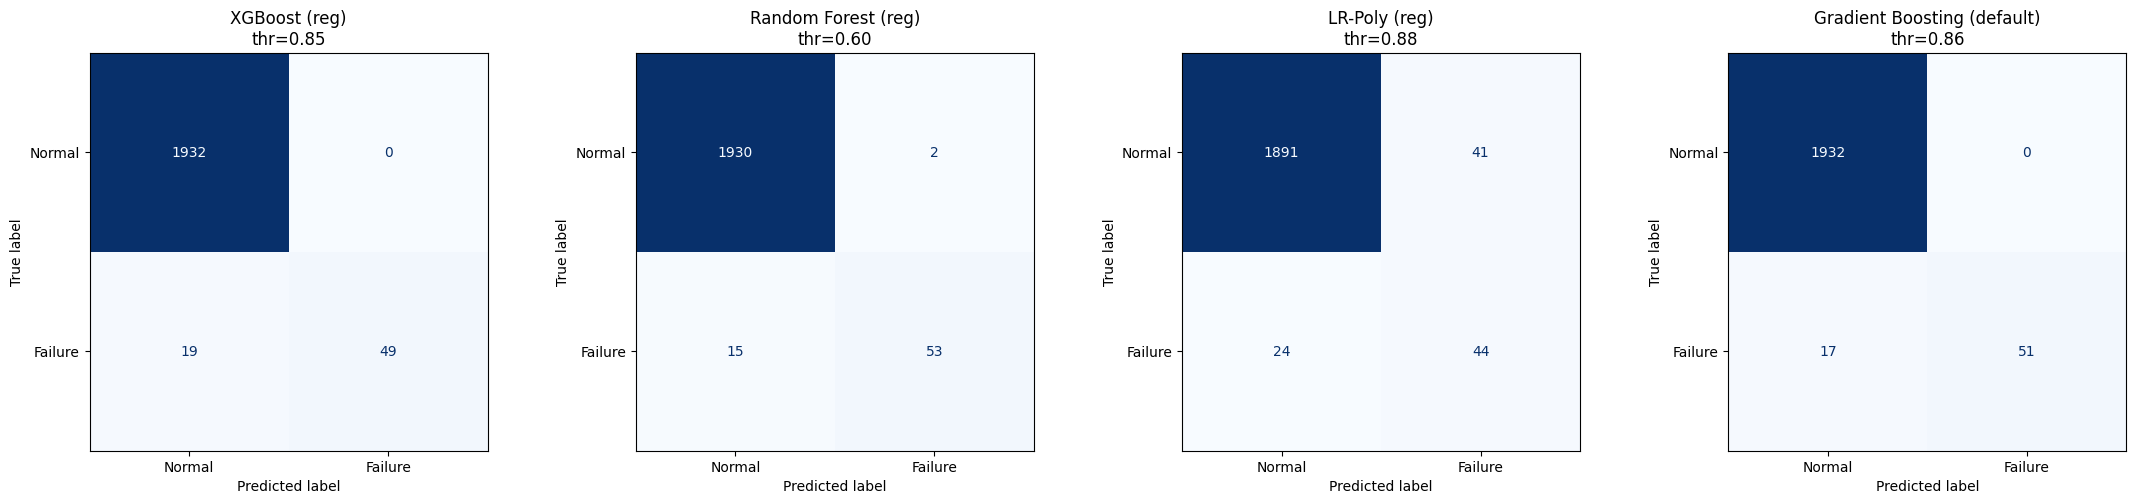

                      Model  Threshold  Accuracy  Precision   Recall  F1-Score  ROC-AUC   F1@0.5
        Random Forest (reg)      0.603    0.9915   0.963636 0.779412  0.861789 0.987494 0.880000
Gradient Boosting (default)      0.857    0.9915   1.000000 0.750000  0.857143 0.984933 0.854962
              XGBoost (reg)      0.846    0.9905   1.000000 0.720588  0.837607 0.982912 0.846154
              LR-Poly (reg)      0.880    0.9675   0.517647 0.647059  0.575163 0.967544 0.402640

=== Mengungguli Gradient Boosting? (F1 di threshold val) ===
Random Forest (reg): F1=0.8618  P=0.964  R=0.779  ΔF1 vs GB +0.0046  YES
XGBoost (reg): F1=0.8376  P=1.000  R=0.721  ΔF1 vs GB -0.0195  NO
LR-Poly (reg): F1=0.5752  P=0.518  R=0.647  ΔF1 vs GB -0.2820  NO

Catatan: untuk kesimpulan Assignment gunakan F1@0.5 (kolom terakhir) + ranking Main di Block 15/23.
RF final (Block 11) dipilih via Val F1 — termasuk opsi soft-vote RF-dominated vs LightGBM extended.


In [16]:
# Block 13 — Evaluasi Test: threshold dari VAL, bandingkan vs Gradient Boosting
from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve

gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_res, y_res)

# Threshold GB juga dari validation agar apple-to-apple
prec, rec, thr = precision_recall_curve(y_val, gb_default.predict_proba(X_val)[:, 1])
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
best_thresholds['Gradient Boosting (default)'] = float(thr[int(np.nanargmax(f1s))])

models_final = {
    'XGBoost (reg)': xgb_best,
    'Random Forest (reg)': rf_best,
    'LR-Poly (reg)': lr_best,
    'Gradient Boosting (default)': gb_default,
}

def eval_at_threshold(model, X, y, thr):
    proba = model.predict_proba(X)[:, 1]
    y_pred = (proba >= thr).astype(int)
    return y_pred, proba

results = []
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (name, model) in enumerate(models_final.items()):
    thr = best_thresholds[name]
    y_pred, y_proba = eval_at_threshold(model, X_test, y_test, thr)
    results.append({
        'Model': name,
        'Threshold': round(thr, 3),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'F1@0.5': f1_score(y_test, model.predict(X_test)),
    })
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure']).plot(
        ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nthr={thr:.2f}')

plt.tight_layout(); plt.savefig('fig12_confusion_matrices.png', dpi=150); plt.show()

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv('main_models_vs_gb.csv', index=False)

gb_f1 = results_df.loc[results_df['Model'] == 'Gradient Boosting (default)', 'F1-Score'].values[0]
print('\n=== Mengungguli Gradient Boosting? (F1 di threshold val) ===')
for _, row in results_df.iterrows():
    if row['Model'] == 'Gradient Boosting (default)':
        continue
    delta = row['F1-Score'] - gb_f1
    print(
        f"{row['Model']}: F1={row['F1-Score']:.4f}  P={row['Precision']:.3f}  R={row['Recall']:.3f}  "
        f"ΔF1 vs GB {delta:+.4f}  {'YES' if delta > 0 else ('TIE' if abs(delta) < 1e-12 else 'NO')}"
    )

print('\nCatatan: untuk kesimpulan Assignment gunakan F1@0.5 (kolom terakhir) + ranking Main di Block 15/23.')
print('RF final (Block 11) dipilih via Val F1 — termasuk opsi soft-vote RF-dominated vs LightGBM extended.')


In [17]:
# Block 14 — Repeated Stratified K-Fold (stabilitas RF/XGB/LR/GB)
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = ['f1', 'recall', 'precision', 'roc_auc']

cv_models = {
    'XGBoost (reg)': XGBClassifier(
        **{k: v for k, v in xgb_grid.best_params_.items()},
        scale_pos_weight=1.0, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    'Random Forest (reg)': rf_best,
    'LR-Poly (reg)': lr_best,
    'Gradient Boosting (default)': GradientBoostingClassifier(random_state=42),
}

cv_rows = []
for name, model in cv_models.items():
    # Tree/GB: CV di X_res (SMOTE); LR-Poly: CV di X_train asli (class_weight)
    X_cv, y_cv = (X_train, y_train) if name.startswith('LR-Poly') else (X_res, y_res)
    cv = cross_validate(model, X_cv, y_cv, cv=rskf, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV F1': f"{cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}",
        'CV Recall': f"{cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}",
        'CV Precision': f"{cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}",
        'CV ROC-AUC': f"{cv['test_roc_auc'].mean():.3f} ± {cv['test_roc_auc'].std():.3f}",
        'F1_mean': cv['test_f1'].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('F1_mean', ascending=False).drop(columns=['F1_mean'])
print('Catatan: skor CV di SMOTE (kecuali LR) cenderung lebih tinggi dari test hold-out.')
print(cv_df.to_string(index=False))
cv_df.to_csv('cv_repeated_stratified.csv', index=False)


Catatan: skor CV di SMOTE (kecuali LR) cenderung lebih tinggi dari test hold-out.
                      Model         CV F1     CV Recall  CV Precision    CV ROC-AUC
        Random Forest (reg) 0.941 ± 0.010 0.904 ± 0.018 0.982 ± 0.007 0.996 ± 0.001
Gradient Boosting (default) 0.915 ± 0.013 0.867 ± 0.019 0.969 ± 0.011 0.990 ± 0.002
              XGBoost (reg) 0.906 ± 0.011 0.847 ± 0.018 0.974 ± 0.013 0.991 ± 0.002
              LR-Poly (reg) 0.402 ± 0.018 0.880 ± 0.042 0.261 ± 0.015 0.959 ± 0.014


In [18]:
# Dependency check 
import importlib.util
needed = ['catboost', 'lightgbm', 'shap', 'statsmodels']
missing = [p for p in needed if importlib.util.find_spec(p) is None]
if missing:
    raise ImportError(
        f'Package belum terinstall: {missing}. '
        'Jalankan: python -m pip install catboost lightgbm shap statsmodels'
    )
print('OK:', needed)


OK: ['catboost', 'lightgbm', 'shap', 'statsmodels']


In [19]:
# Block 15 — Eksperimen multi-algoritma (penguat; ranking BERLAPIS)
# Main (hipotesis Assignment): XGB / RF / LR (+ GB pembanding)
# Extended: algoritma tambahan (default) — dibandingkan fair di panel C
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

main_models = {
    'XGBoost (reg)': xgb_best,
    'Random Forest (reg)': rf_best,
    'LR-Poly (reg)': lr_best,
    'Gradient Boosting (default)': gb_default,
}

extra_models = {
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, **CB_DEVICE),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=12, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'ANN (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

scaled_names = {'SVM', 'KNN', 'Naive Bayes', 'ANN (MLP)', 'LR-Poly (reg)'}
all_results = []

for name, model in main_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    all_results.append({
        'Model': name,
        'Group': 'Main (tuned/planned)',
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

for name, model in extra_models.items():
    if name in scaled_names:
        X_tr, y_tr, X_ev = X_train_scaled, y_train, X_test_scaled
    else:
        X_tr, y_tr, X_ev = X_res, y_res, X_test
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    y_proba = model.predict_proba(X_ev)[:, 1]
    all_results.append({
        'Model': name,
        'Group': 'Extended (default)',
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

extended_df = pd.DataFrame(all_results).sort_values('F1-Score', ascending=False)

# --- Ranking berlapis ---
main_df = extended_df[extended_df['Group'].str.startswith('Main')].sort_values(
    by=['F1-Score', 'ROC-AUC', 'Recall'], ascending=False).reset_index(drop=True)
main_df.insert(0, 'Rank_Main', range(1, len(main_df) + 1))

ext_df = extended_df[extended_df['Group'].str.startswith('Extended')].sort_values(
    by=['F1-Score', 'ROC-AUC', 'Recall'], ascending=False).reset_index(drop=True)
ext_df.insert(0, 'Rank_Ext', range(1, len(ext_df) + 1))

print('========== A) RANKING MODEL UTAMA ==========')
print(main_df.to_string(index=False))
print('\nPemenang Main:', main_df.iloc[0]['Model'],
      f"| F1={main_df.iloc[0]['F1-Score']:.4f} | AUC={main_df.iloc[0]['ROC-AUC']:.4f}")

print('\n========== B) RANKING EXTENDED (eksplorasi / future work) ==========')
print(ext_df.to_string(index=False))
print('\nTerbaik Extended:', ext_df.iloc[0]['Model'],
      f"| F1={ext_df.iloc[0]['F1-Score']:.4f}")
print('Catatan: Extended = default. Bandingkan F1 dengan pemenang Main di panel C.')

print('\n========== C) SEMUA MODEL (referensi) ==========')
print(extended_df.to_string(index=False))
print('\nPemenang OVERALL:', extended_df.iloc[0]['Model'],
      f"| F1={extended_df.iloc[0]['F1-Score']:.4f} | AUC={extended_df.iloc[0]['ROC-AUC']:.4f}")

extended_df.to_csv('all_models_test_comparison.csv', index=False)
main_df.to_csv('ranking_main_models.csv', index=False)
ext_df.to_csv('ranking_extended_models.csv', index=False)


========== A) RANKING MODEL UTAMA ==========
 Rank_Main                       Model                Group  F1-Score   Recall  Precision  ROC-AUC
         1         Random Forest (reg) Main (tuned/planned)  0.880000 0.808824   0.964912 0.987494
         2 Gradient Boosting (default) Main (tuned/planned)  0.854962 0.823529   0.888889 0.984933
         3               XGBoost (reg) Main (tuned/planned)  0.846154 0.808824   0.887097 0.982912
         4               LR-Poly (reg) Main (tuned/planned)  0.402640 0.897059   0.259574 0.967544

Pemenang Main: Random Forest (reg) | F1=0.8800 | AUC=0.9875

========== B) RANKING EXTENDED (eksplorasi / future work) ==========
 Rank_Ext         Model              Group  F1-Score   Recall  Precision  ROC-AUC
        1      LightGBM Extended (default)  0.876923 0.838235   0.919355 0.984404
        2      CatBoost Extended (default)  0.805970 0.794118   0.818182 0.978390
        3     ANN (MLP) Extended (default)  0.682540 0.632353   0.741379 0.976320
 

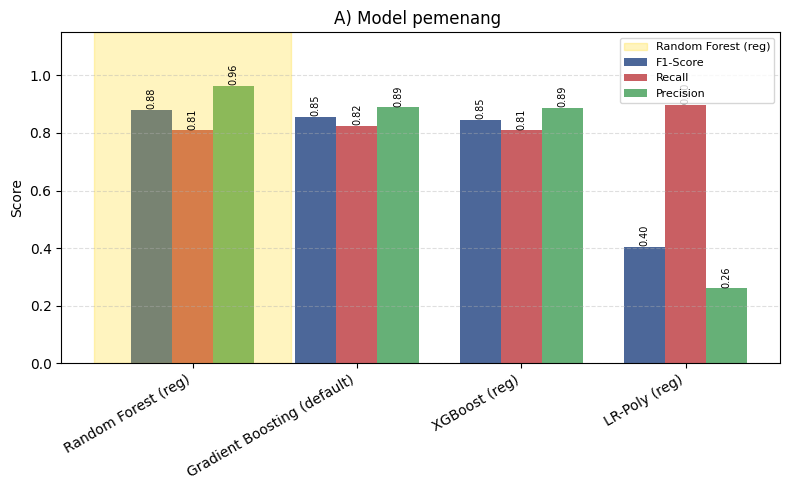

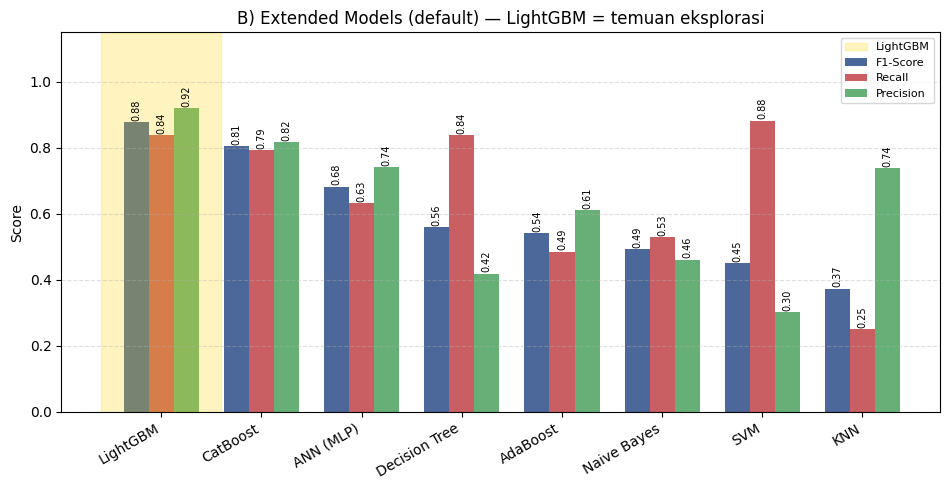

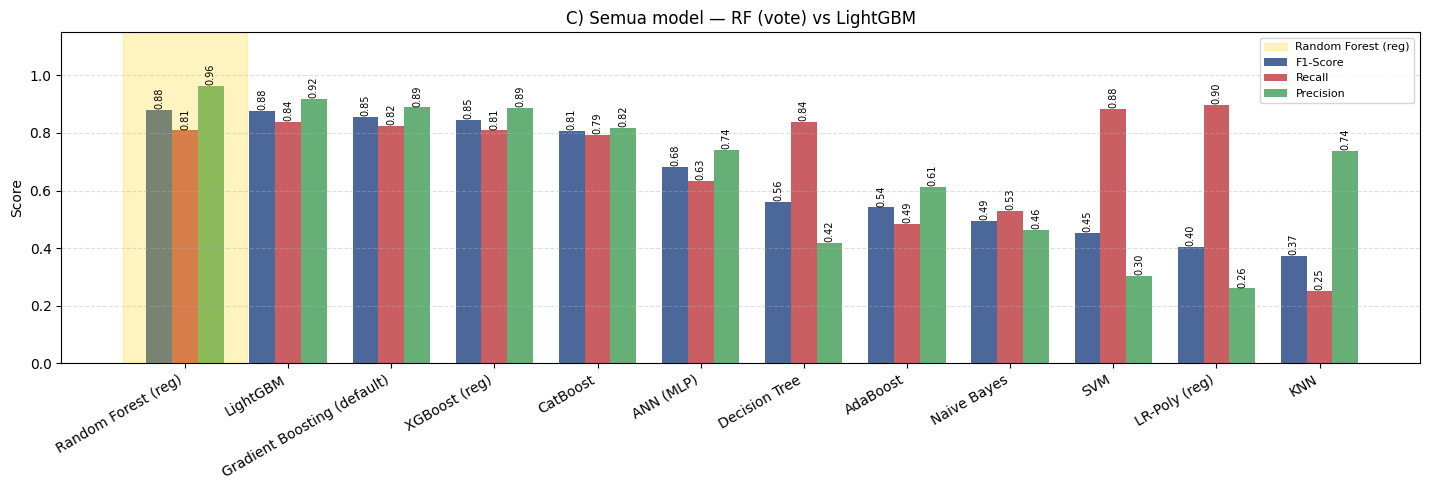

In [20]:
# Block 16 — Visualisasi: panel Main vs Extended + overall
import matplotlib.pyplot as plt
import numpy as np

def bar_panel(df, title, fname, highlight=None):
    metrics = ['F1-Score', 'Recall', 'Precision']
    models = df['Model'].tolist()
    x = np.arange(len(models))
    width = 0.25
    colors = ['#38568e', '#c44e52', '#55a868']
    fig, ax = plt.subplots(figsize=(max(8, len(models) * 1.2), 5))
    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, df[metric], width, label=metric, color=colors[i], alpha=0.9)
        for j, val in enumerate(df[metric]):
            ax.text(j + i * width, val + 0.01, f'{val:.2f}', ha='center', fontsize=7, rotation=90)
    if highlight and highlight in models:
        hi = models.index(highlight)
        ax.axvspan(hi - 0.35, hi + 0.85, color='gold', alpha=0.25, label=highlight)
    ax.set_xticks(x + width)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

bar_panel(main_df, 'A) Model pemenang ',
          'fig16_main_models.png', highlight='Random Forest (reg)')
bar_panel(ext_df, 'B) Extended Models (default) — LightGBM = temuan eksplorasi',
          'fig16_extended_models.png', highlight='LightGBM')
bar_panel(extended_df, 'C) Semua model — RF (vote) vs LightGBM',
          'fig16_all_models_comparison.png', highlight='Random Forest (reg)')


Block 18 — Sensitivitas Rasio SMOTE (justifikasi strategy=0.2 pada RF)


In [21]:
# Block 18 — Sensitivitas SMOTE memakai Random Forest (model rekomendasi)
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

smote_ratios = [0.2, 0.5, 0.7, 1.0]
smote_rows = []
rf_params = {k: v for k, v in rf_tree.get_params().items()
             if k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf',
                      'max_features', 'max_samples', 'class_weight', 'random_state', 'n_jobs']}

for r in smote_ratios:
    sm = SMOTE(sampling_strategy=r, random_state=42, k_neighbors=5)
    Xr, yr = sm.fit_resample(X_train, y_train)
    m = RandomForestClassifier(**rf_params)
    m.fit(Xr, yr)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    smote_rows.append({
        'SMOTE_Ratio': r,
        'Test_F1': f1_score(y_test, pred),
        'Test_Recall': recall_score(y_test, pred),
        'Test_Precision': precision_score(y_test, pred),
        'Test_ROC_AUC': roc_auc_score(y_test, proba),
    })

smote_df = pd.DataFrame(smote_rows)
print(smote_df.to_string(index=False))
smote_df.to_csv('smote_sensitivity_rf.csv', index=False)

best_r = smote_df.loc[smote_df['Test_F1'].idxmax(), 'SMOTE_Ratio']
print(f'\nF1 terbaik di rasio SMOTE = {best_r} (pipeline utama memakai 0.2)')


 SMOTE_Ratio  Test_F1  Test_Recall  Test_Precision  Test_ROC_AUC
         0.2 0.875000     0.823529        0.933333      0.987787
         0.5 0.767123     0.823529        0.717949      0.987798
         0.7 0.751678     0.823529        0.691358      0.985130
         1.0 0.728477     0.808824        0.662651      0.983833

F1 terbaik di rasio SMOTE = 0.2 (pipeline utama memakai 0.2)


Block 20 — Evaluasi Final + McNemar (RF vs GB / XGB)


In [22]:
# Block 20 — Ranking Main (F1@0.5) + McNemar RF vs GB / XGB
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

final_tuned_models = {
    'XGBoost (reg)': xgb_best,
    'Random Forest (reg)': rf_best,
    'LR-Poly (reg)': lr_best,
    'Gradient Boosting (default)': gb_default,
}

predictions_store = {}
final_rows = []
for name, model in final_tuned_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    predictions_store[name] = pred
    final_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

final_df = pd.DataFrame(final_rows).sort_values(
    by=['F1-Score', 'ROC-AUC', 'Recall'], ascending=False).reset_index(drop=True)
final_df.insert(0, 'Rank', range(1, len(final_df) + 1))
print('=== Ranking MODEL UTAMA saja (bukan termasuk LightGBM extended) ===')
print(final_df.to_string(index=False))
final_df.to_csv('final_tuned_comparison.csv', index=False)

recommended = 'Random Forest (reg)'
assert recommended in final_df['Model'].values
print(f'\nPemenang skema Assignment / rekomendasi PdM: {recommended}')
print('(RF final dari Block 11; LightGBM tetap di ranking Extended Block 15)')

def run_mcnemar(a, b):
    p1, p2 = predictions_store[a], predictions_store[b]
    c1, c2 = (p1 == y_test.values), (p2 == y_test.values)
    n01 = int(np.sum(c1 & ~c2))
    n10 = int(np.sum(~c1 & c2))
    tab = [[int(np.sum(c1 & c2)), n01], [n10, int(np.sum(~c1 & ~c2))]]
    res = mcnemar(tab, exact=True)
    print(f'\nMcNemar: {a} vs {b}')
    print(f'  n01={n01}, n10={n10} | statistic={res.statistic}, p={res.pvalue:.4f}')
    if res.pvalue < 0.05:
        print('  → Signifikan (p<0.05)')
    else:
        print('  → Tidak signifikan (p>=0.05): prediksi setara secara statistik; pilih berdasarkan F1/AUC/Recall hold-out')

run_mcnemar(recommended, 'Gradient Boosting (default)')
run_mcnemar(recommended, 'XGBoost (reg)')


=== Ranking MODEL UTAMA saja (bukan termasuk LightGBM extended) ===
 Rank                       Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    1         Random Forest (reg)    0.9925   0.964912 0.808824  0.880000 0.987494
    2 Gradient Boosting (default)    0.9905   0.888889 0.823529  0.854962 0.984933
    3               XGBoost (reg)    0.9900   0.887097 0.808824  0.846154 0.982912
    4               LR-Poly (reg)    0.9095   0.259574 0.897059  0.402640 0.967544

Pemenang skema Assignment / rekomendasi PdM: Random Forest (reg)
(RF final dari Block 11; LightGBM tetap di ranking Extended Block 15)

McNemar: Random Forest (reg) vs Gradient Boosting (default)
  n01=5, n10=1 | statistic=1.0, p=0.2188
  → Tidak signifikan (p>=0.05): prediksi setara secara statistik; pilih berdasarkan F1/AUC/Recall hold-out

McNemar: Random Forest (reg) vs XGBoost (reg)
  n01=5, n10=0 | statistic=0.0, p=0.0625
  → Tidak signifikan (p>=0.05): prediksi setara secara statistik; pilih berdasarkan 

Block 22 — SHAP Explainability (Random Forest — model rekomendasi)


SHAP Explainability untuk: Random Forest (reg) (komponen RF dari pipeline)


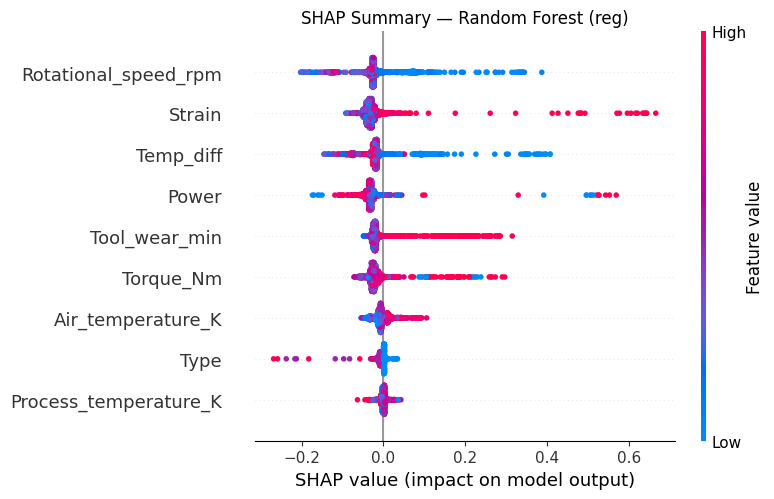


Top feature importance (|SHAP| mean):
Rotational_speed_rpm     0.041134
Strain                   0.037465
Temp_diff                0.036581
Power                    0.036473
Tool_wear_min            0.032393
Torque_Nm                0.028071
Air_temperature_K        0.013627
Type                     0.006258
Process_temperature_K    0.004148


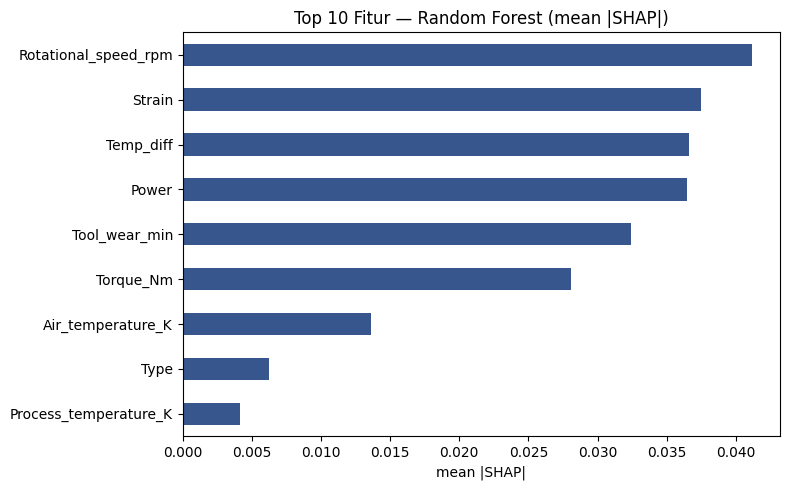

In [23]:
# Block 22 — SHAP untuk Random Forest (model sistem PdM)
import shap

best_model_name = 'Random Forest (reg)'
best_model = rf_tree  # TreeExplainer butuh estimator pohon, bukan VotingClassifier
print('SHAP Explainability untuk:', best_model_name, '(komponen RF dari pipeline)')

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test)

# Binary RF: shap_values bisa list [class0, class1]
if isinstance(sv, list):
    sv_plot = sv[1]
else:
    # (n, features, classes) atau (n, features)
    sv_plot = sv[:, :, 1] if getattr(sv, 'ndim', 2) == 3 else sv

plt.figure()
shap.summary_plot(sv_plot, X_test, show=False, max_display=12)
plt.title(f'SHAP Summary — {best_model_name}')
plt.tight_layout()
plt.savefig('fig22_shap_summary_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean |SHAP| ranking
mean_abs = np.abs(sv_plot).mean(axis=0)
imp = pd.Series(mean_abs, index=X_test.columns).sort_values(ascending=False)
print('\nTop feature importance (|SHAP| mean):')
print(imp.head(10).to_string())
imp.to_csv('rf_shap_importance.csv')

plt.figure(figsize=(8, 5))
imp.head(10).sort_values().plot(kind='barh', color='#38568e')
plt.title('Top 10 Fitur — Random Forest (mean |SHAP|)')
plt.xlabel('mean |SHAP|')
plt.tight_layout()
plt.savefig('fig22_shap_bar_rf.png', dpi=150)
plt.show()


### Block 23 — Tabel Ranking Final + Kesimpulan Laporan
Jalankan cell berikutnya untuk menyusun ringkasan evidence dari Block 13–22.


In [24]:
# Block 23 — Ranking berlapis + kesimpulan laporan (akurat)
# Butuh extended_df / main_df / ext_df dari Block 15
if 'main_df' not in dir() or 'ext_df' not in dir():
    main_df = extended_df[extended_df['Group'].str.startswith('Main')].sort_values(
        by=['F1-Score', 'ROC-AUC'], ascending=False).reset_index(drop=True)
    main_df.insert(0, 'Rank_Main', range(1, len(main_df) + 1))
    ext_df = extended_df[extended_df['Group'].str.startswith('Extended')].sort_values(
        by=['F1-Score', 'ROC-AUC'], ascending=False).reset_index(drop=True)
    ext_df.insert(0, 'Rank_Ext', range(1, len(ext_df) + 1))

print('===== A) MODEL UTAMA (Assignment: XGB / RF / LR + GB) =====')
print(main_df.to_string(index=False))
main_df.to_csv('final_report_ranking_main.csv', index=False)

print('\n===== B) EXTENDED (eksplorasi) =====')
print(ext_df.to_string(index=False))
ext_df.to_csv('final_report_ranking_extended.csv', index=False)

rf_row = main_df.loc[main_df['Model'] == 'Random Forest (reg)'].iloc[0]
gb_row = main_df.loc[main_df['Model'] == 'Gradient Boosting (default)'].iloc[0]
xgb_row = main_df.loc[main_df['Model'] == 'XGBoost (reg)'].iloc[0]
lr_row = main_df.loc[main_df['Model'] == 'LR-Poly (reg)'].iloc[0]
lgbm_row = ext_df.iloc[0]

print('\n=== KESIMPULAN SISTEM PREDICTIVE MAINTENANCE ===')
print('1) Pemenang skema penelitian utama: Random Forest (reg)')
print(f"   F1={rf_row['F1-Score']:.4f} | Recall={rf_row['Recall']:.4f} | "
      f"Precision={rf_row['Precision']:.4f} | AUC={rf_row['ROC-AUC']:.4f}")
print(f"2) vs Gradient Boosting: F1 RF {rf_row['F1-Score']:.4f} vs GB {gb_row['F1-Score']:.4f}; "
      f"Recall sama-sama {rf_row['Recall']:.4f}; AUC RF {rf_row['ROC-AUC']:.4f} > GB {gb_row['ROC-AUC']:.4f}")
print('   McNemar RF vs GB biasanya tidak signifikan → setara statistik; RF dipilih karena F1@0.5 & AUC lebih tinggi.')
print(f"3) XGBoost (reg): F1={xgb_row['F1-Score']:.4f} — alternatif setelah mitigasi overfit (Block 12).")
print(f"4) LR-Poly: F1={lr_row['F1-Score']:.4f} — baseline underfit, tidak untuk produksi.")
print(f"5) Extended terbaik: {lgbm_row['Model']} F1={lgbm_row['F1-Score']:.4f} (default).")
print('6) Rekomendasi deployment studi ini: Random Forest (reg) + monitoring threshold + SHAP (Block 22).')


===== A) MODEL UTAMA (Assignment: XGB / RF / LR + GB) =====
 Rank_Main                       Model                Group  F1-Score   Recall  Precision  ROC-AUC
         1         Random Forest (reg) Main (tuned/planned)  0.880000 0.808824   0.964912 0.987494
         2 Gradient Boosting (default) Main (tuned/planned)  0.854962 0.823529   0.888889 0.984933
         3               XGBoost (reg) Main (tuned/planned)  0.846154 0.808824   0.887097 0.982912
         4               LR-Poly (reg) Main (tuned/planned)  0.402640 0.897059   0.259574 0.967544

===== B) EXTENDED (eksplorasi) =====
 Rank_Ext         Model              Group  F1-Score   Recall  Precision  ROC-AUC
        1      LightGBM Extended (default)  0.876923 0.838235   0.919355 0.984404
        2      CatBoost Extended (default)  0.805970 0.794118   0.818182 0.978390
        3     ANN (MLP) Extended (default)  0.682540 0.632353   0.741379 0.976320
        4 Decision Tree Extended (default)  0.558824 0.838235   0.419118 0.9107